__Markus Mulvihill__

__Last updated May 2026__

# Necessary Packages and Modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tomllib
import plt_config

# Introduction

This file examines the accuracy and time complexity of the extended Kalman filter and the particle filter with various number of particles.

In [2]:
try:
    time_arr_03 = np.load("../scripts/saved_variables/module3/time_arr_03_temp.npy")
    error_arr_03 = np.load("../scripts/saved_variables/module3/error_arr_03_temp.npy")
    G_ests = np.load("../scripts/saved_variables/module3/G_ests_03_temp.npy")
    G_trues = np.load("../scripts/saved_variables/module3/G_trues_03_temp.npy")
    # all_vars = np.load("../scripts/saved_variables/module3/vars_03_temp.npy")
    states = np.load("../scripts/saved_variables/module3/states_03_temp.npy")
    print("Loaded variables")
except Exception:
    print("Run 03_Estimator_Comparison.py")

Loaded variables


In [3]:
with open("../config.toml", "rb") as f:
    cfg = tomllib.load(f)
curr_module = "03"
num_particles = cfg[curr_module]["num_particles"]
low_perc = cfg[curr_module]["low_perc"]
high_perc = cfg[curr_module]["high_perc"]
CI = cfg[curr_module]["CI"]
converge_time = cfg[curr_module]["converge_time"]
deviations = cfg[curr_module]["deviations"]
dev_perc = cfg[curr_module]["dev_perc"]
plot_particles_idx = cfg[curr_module]["plot_particles_idx"]
num_deviations = len(deviations)
num_patients = cfg[curr_module]["num_patients"]

# Plot Results

<Axes: xlabel='Estimator', ylabel='Time to run (s)'>

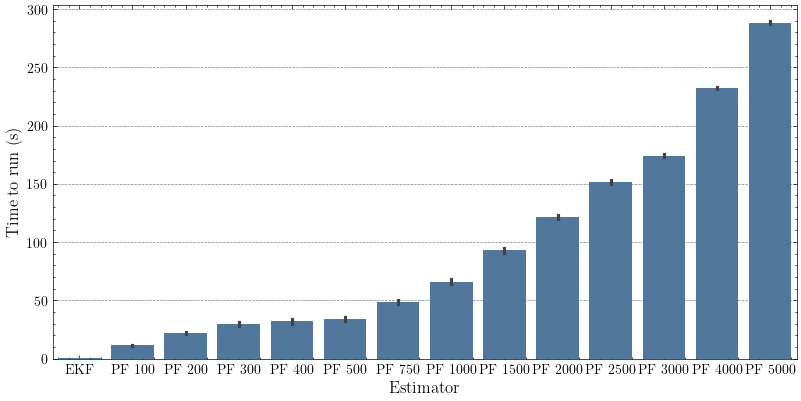

In [4]:
mean_time_run = np.average(time_arr_03[0, :, :].T, axis=0)
filters = ["EKF"]
pfs = [f"PF {particles}" for particles in num_particles]
filters.extend(pfs)
df = pd.DataFrame(time_arr_03[0, :, :].T, columns=filters).melt(
    var_name="Estimator", value_name="Time to run (s)"
)

fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(df, x="Estimator", y="Time to run (s)", ax=ax)

<>:35: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:35: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
/var/folders/2r/d34tnm611fn3fckxlfmjl03r0000gn/T/ipykernel_76888/453375046.py:35: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
  ax.set_title(f"Initial State Deviation of {dev_perc[j]} \%")


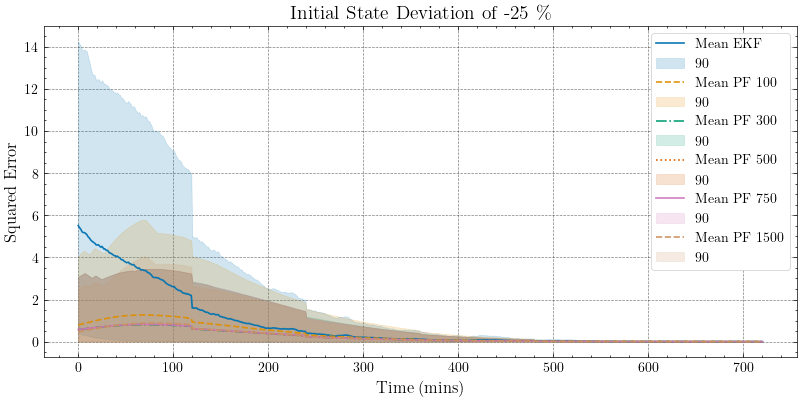

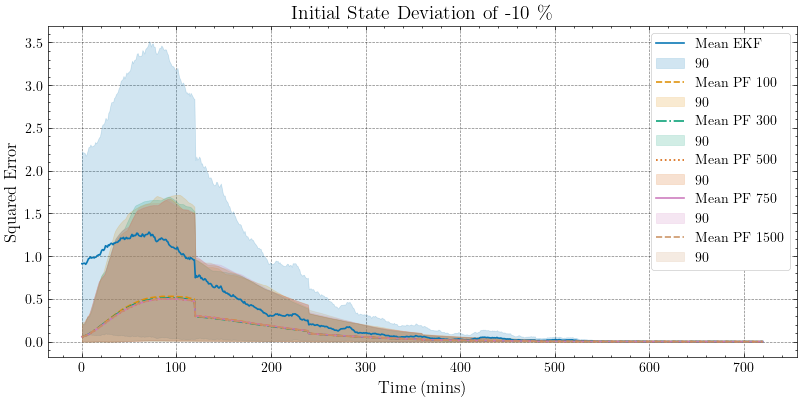

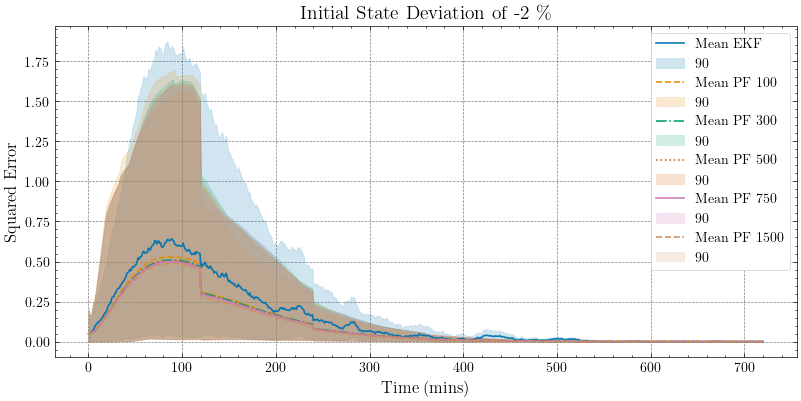

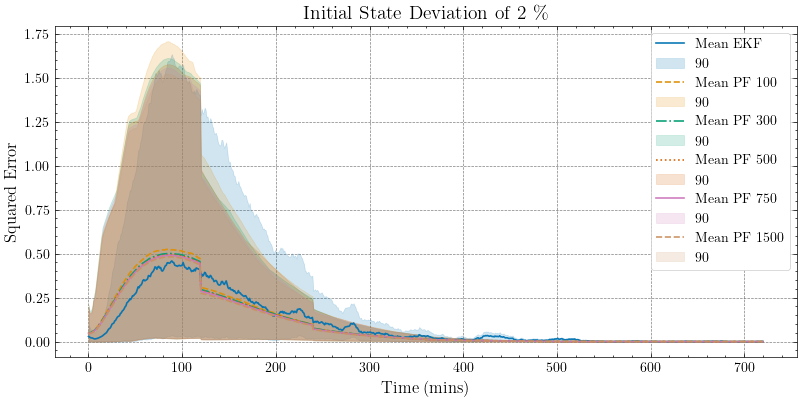

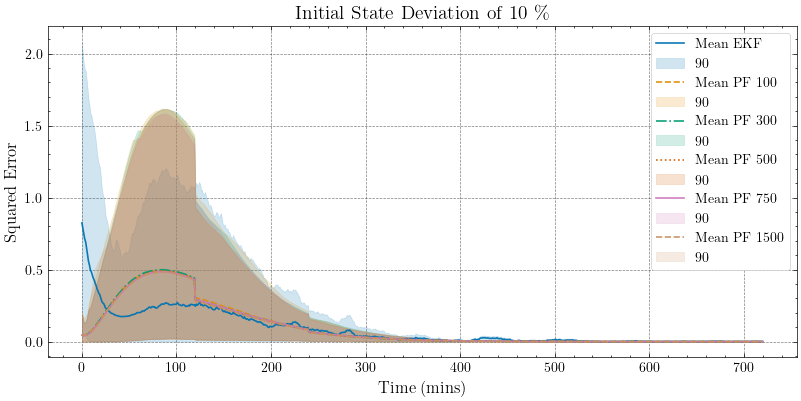

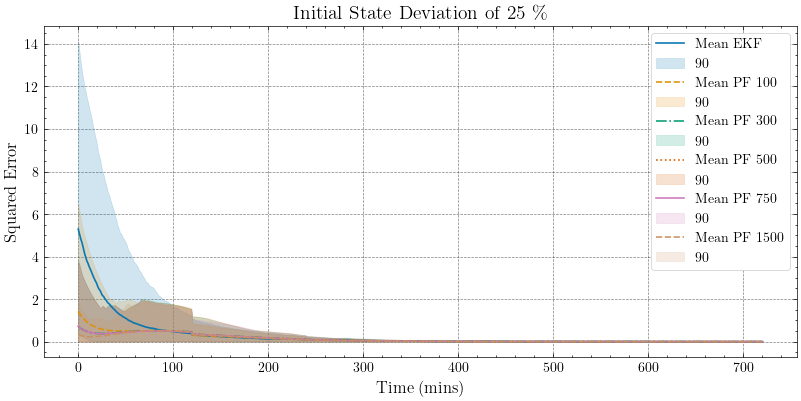

In [5]:
for j in range(num_deviations):
    mean_err = np.mean(error_arr_03[j, :, :, :], axis=1)
    ci_low = np.percentile(error_arr_03[j, :, :, :], low_perc, axis=1)
    ci_high = np.percentile(error_arr_03[j, :, :, :], high_perc, axis=1)
    time = np.arange(mean_err.shape[1])
    num_plots = len(plot_particles_idx)  #
    num_filters = len(filters)
    palette = sns.color_palette("colorblind", num_filters)

    # fig, ax = plt.subplots(2,1, sharex='col', sharey=True, figsize=(12,5))
    fig, ax = plt.subplots(figsize=(8,4))

    for i in range(num_plots):
        plot_idx = plot_particles_idx[i]
        ax.plot(
            time,
            mean_err[plot_idx],
            color=palette[i],
            linewidth=1.2,
            alpha=0.95,
            linestyle=["-", "--", "-.", ":"][i % 4],
            label=f"Mean {filters[plot_idx]}",
        )
        ax.fill_between(
            time,
            ci_low[plot_idx],
            ci_high[plot_idx],
            color=palette[i],
            alpha=0.18,
            label=f"{CI}% CI",
        )
    ax.set_ylabel("Squared Error")
    ax.legend(loc="best")
    ax.set_xlabel("Time (mins)")
    ax.set_title(f"Initial State Deviation of {dev_perc[j]} \%")

<>:19: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:19: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
/var/folders/2r/d34tnm611fn3fckxlfmjl03r0000gn/T/ipykernel_76888/5250148.py:19: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
  ax.set_title(f"Patient {i + 1} with {dev_perc[deviation]} \% deviation")


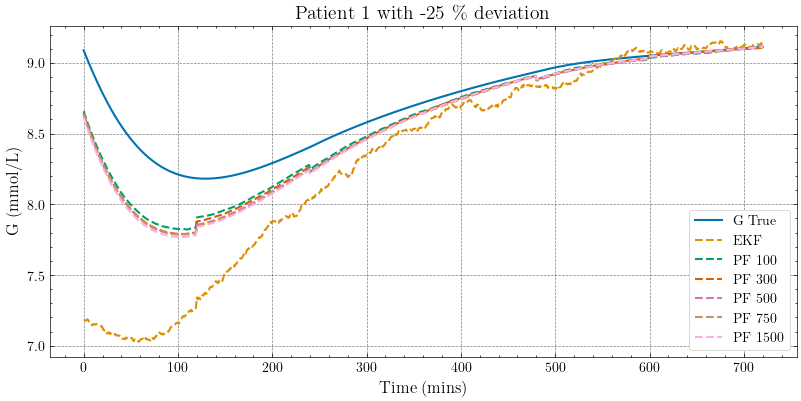

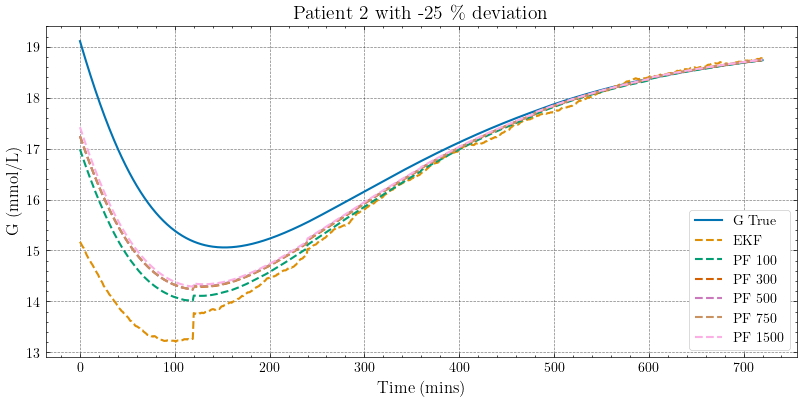

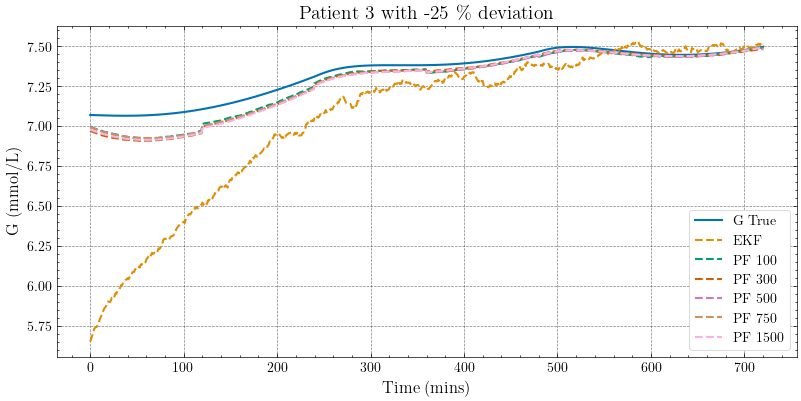

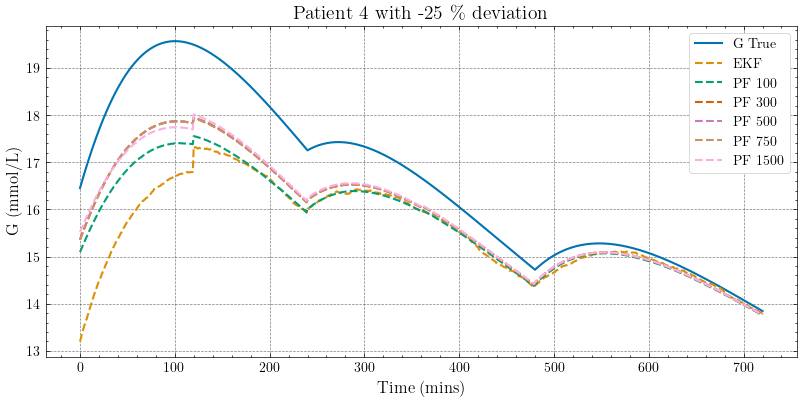

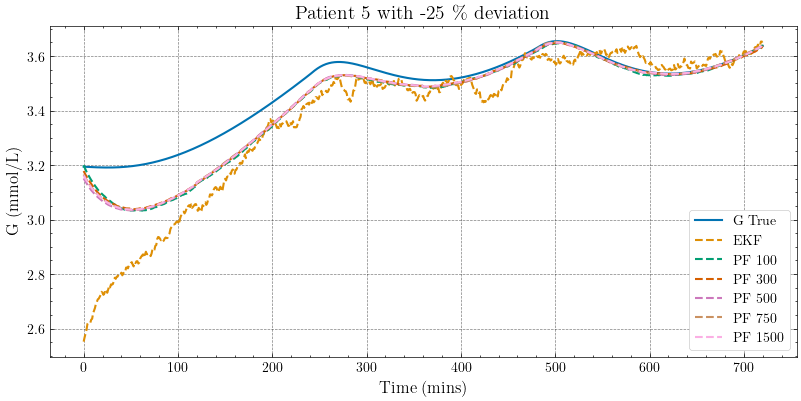

In [6]:
deviation = 0
palette = sns.color_palette("colorblind", num_filters + 1)
for i in range(5):
    fig, ax = plt.subplots(figsize=(8,4))
    ax.plot(time, G_trues[i, :], color=palette[0], label="G True")
    for j in range(num_plots):
        plot_idx = plot_particles_idx[j]
        # G_est = states[deviation, plot_idx, i, :, 2]
        G_est = G_ests[deviation, plot_idx, i, :]
        #G_std = np.sqrt(all_vars[deviation, plot_idx, i, :, 0, 0])
        ax.plot(
            time,
            G_est,
            linestyle="--",
            color=palette[j + 1],
            label=f"{filters[plot_idx]}",
        )
        
    ax.set_title(f"Patient {i + 1} with {dev_perc[deviation]} \% deviation")
    ax.legend()
    ax.set_xlabel("Time (mins)")
    ax.set_ylabel("G (mmol/L)")

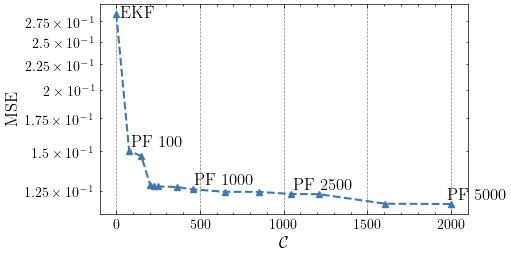

In [7]:
total_avg_time = np.average(time_arr_03, axis=(0, 2))
complexity = total_avg_time / min(total_avg_time)
total_avg_err = np.average(error_arr_03, axis=(0, 2, 3))

fig, ax = plt.subplots(figsize=(5.1,2.55))
ax.semilogy(complexity, total_avg_err, linestyle="--", marker="^")
ax.set_xlabel(r"$\mathcal{C}$")
ax.set_ylabel("MSE")
for x, y, label in zip(complexity, total_avg_err, filters):
    if label in {"EKF", "PF 100", "PF 1000", "PF 2500", "PF 5000"}:
        if label == "EKF":
            ax.annotate(label, xy=(x, y), xytext=(3,-5), textcoords="offset points", ha="left", va="bottom")
        elif label == "PF 5000":
            ax.annotate(label, xy=(x, y), xytext=(-3,1), textcoords="offset points", ha="left", va="bottom")
        else:
            ax.annotate(label, xy=(x, y), xytext=(1,1), textcoords="offset points", ha="left", va="bottom")
fig.savefig("figures/5_6.pdf", format="pdf")

In [8]:
print("Total average complexity: \n", complexity)
print("Total average MSE: \n", total_avg_err)

deviation_error = np.average(error_arr_03, axis=(2,3))
deviation_std = np.std(error_arr_03, axis=(2,3))
# print("MSE per deviation: \n", deviation_error)
print("SD per deviation: \n", deviation_std)

Total average complexity: 
 [1.00000000e+00 7.75695610e+01 1.50945402e+02 2.03376237e+02
 2.24316507e+02 2.51516866e+02 3.62775926e+02 4.58364974e+02
 6.48263100e+02 8.51076476e+02 1.04457652e+03 1.20953614e+03
 1.60533689e+03 1.99974686e+03]
Total average MSE: 
 [0.284443   0.15052577 0.14670097 0.12831482 0.12791117 0.1274661
 0.12714851 0.12574609 0.12432222 0.12431961 0.12306709 0.12299216
 0.11764147 0.11747163]
SD per deviation: 
 [[2.07589568 0.96777499 0.957467   0.66303826 0.6645182  0.6634905
  0.66567817 0.66771815 0.68220071 0.68836112 0.68849944 0.68641613
  0.5751128  0.57423198]
 [0.62052684 0.27301124 0.25863405 0.26316394 0.26101603 0.25989818
  0.26071404 0.26175192 0.26120896 0.25896201 0.25787672 0.25849998
  0.25951505 0.25844234]
 [0.30080898 0.26847576 0.2644254  0.25799593 0.25490344 0.25441573
  0.25152771 0.24702757 0.24314009 0.24360814 0.24357655 0.2425868
  0.24230991 0.24188974]
 [0.23071644 0.26576461 0.25766005 0.25323436 0.24947354 0.24998806
  0.245526